In [13]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq
from langgraph.checkpoint.memory import MemorySaver

In [3]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv(override=True)

model = ChatGroq(
    model="llama-3.3-70b-versatile",
    groq_api_key=os.getenv("GROQ_API_KEY"),
)

print(model.invoke("Reply with exactly: API key works").content)

API key works


In [4]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [5]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [ ]:
def chat_node(state: ChatState):

    # take user query from state
    messages = state['messages']

    # send to llm
    response = llm.invoke(messages)

    # response store state
    return {'messages': [response]}

In [14]:
checkpointer = MemorySaver()
graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer=checkpointer)

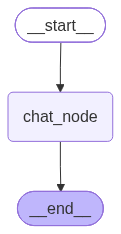

In [15]:
chatbot

In [ ]:
initial_state = {
    'messages': [HumanMessage(content='What is the capital of usa')]
}

chatbot.invoke(initial_state)['messages'][-1].content

In [17]:
thread_id = '1'

while True:

    user_message = input('Type here: ')

    if user_message.strip().lower() in ['exit', 'bye', 'quit']:
        break

    config = {'configurable': {'thread_id':thread_id}}
    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]}, config=config)

    print('AI:',response['messages'][-1].content)

AI: It's nice to meet you. Is there something I can help you with or would you like to chat?
AI: Nice to meet you, Ansh. How's your day going so far?
AI: Your name is Ansh.
AI: 20 + 30 = 50
AI: 50 + 5 = 55
AI: See you later, Ansh. Have a great day! Bye!


In [18]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='f4d90951-5e15-4c18-9e24-8173f76cf524'), AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.046085162, 'completion_tokens_details': None, 'prompt_time': 0.001702786, 'prompt_tokens_details': None, 'queue_time': 0.051812763, 'total_time': 0.047787948}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f9d0c-e707-7af1-a39b-10a465980220-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59}), HumanMessage(content='my name is ansh', additional_kwargs={}, response_metadata={}, id=